# Instructor Effectiveness Modeling

Predicting instructor effectiveness tiers (Low/Medium/High) from batch-level EdTech data. Each row is one instructor–batch–course combination with completion, quiz, engagement, and feedback metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print('All imports loaded successfully.')

All imports loaded successfully.


In [2]:
df = pd.read_csv('data.csv')
print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset loaded: 2000 rows × 12 columns


In [3]:
print(df.shape)
print()
df.head()

(2000, 12)



,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [5]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [6]:
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing: {missing.sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

Total missing: 0
Duplicate rows: 0


In [7]:
n_instructors = df['instructor_id'].nunique()
n_courses = df['course_id'].nunique()

batches_per_instructor = df.groupby('instructor_id')['batch_id'].count()

print(f'Unique instructors: {n_instructors}')
print(f'Unique courses:     {n_courses}')
print(f'Batches per instructor — min: {batches_per_instructor.min()}, '
      f'max: {batches_per_instructor.max()}, mean: {batches_per_instructor.mean():.2f}')

Unique instructors: 120
Unique courses:     25
Batches per instructor — min: 7, max: 31, mean: 16.67


2000 rows, 12 columns, no missing values, no duplicates. 120 instructors across 25 courses, with 7–31 batches each (mean ~17). Nine float columns for metrics, three object columns for IDs.

Histograms with KDE for all 9 numeric columns to check distributions.

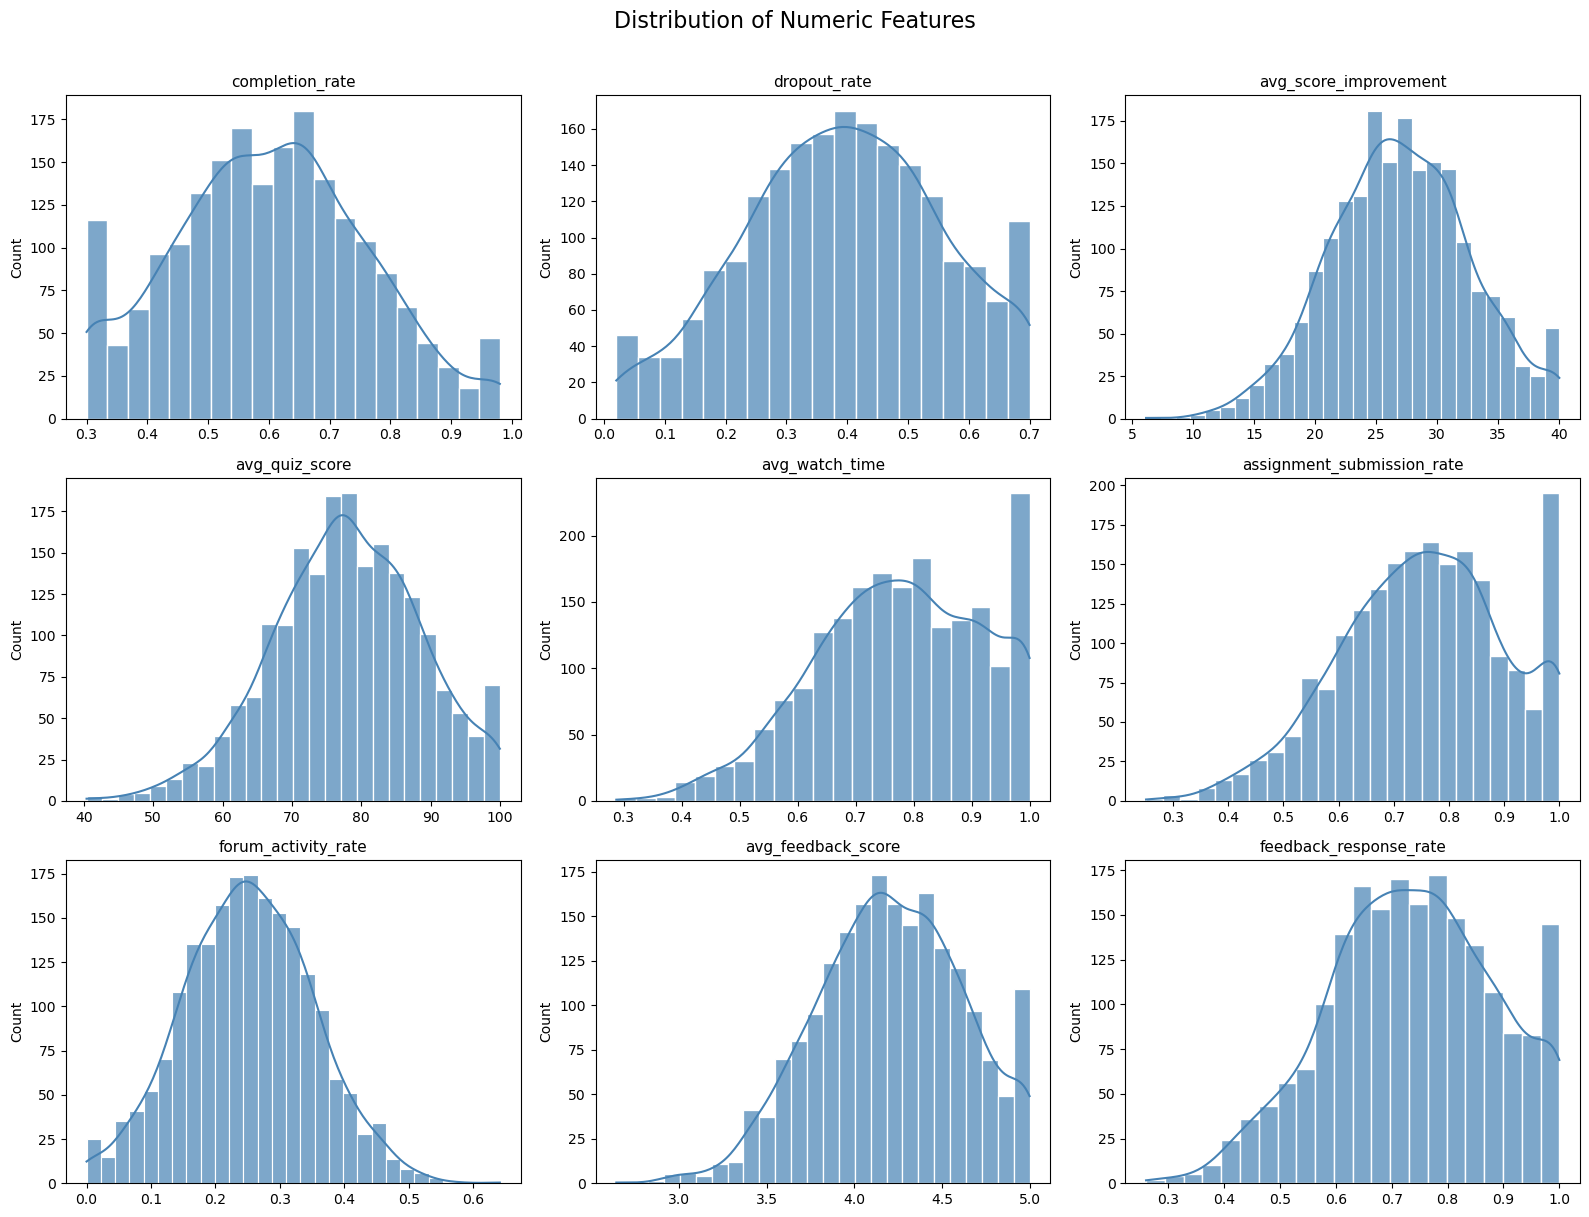

In [8]:
numeric_cols = [
    'completion_rate', 'dropout_rate', 'avg_score_improvement',
    'avg_quiz_score', 'avg_watch_time', 'assignment_submission_rate',
    'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Distribution of Numeric Features', fontsize=16, y=1.01)

for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', edgecolor='white', alpha=0.7)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation heatmap for all numeric features.

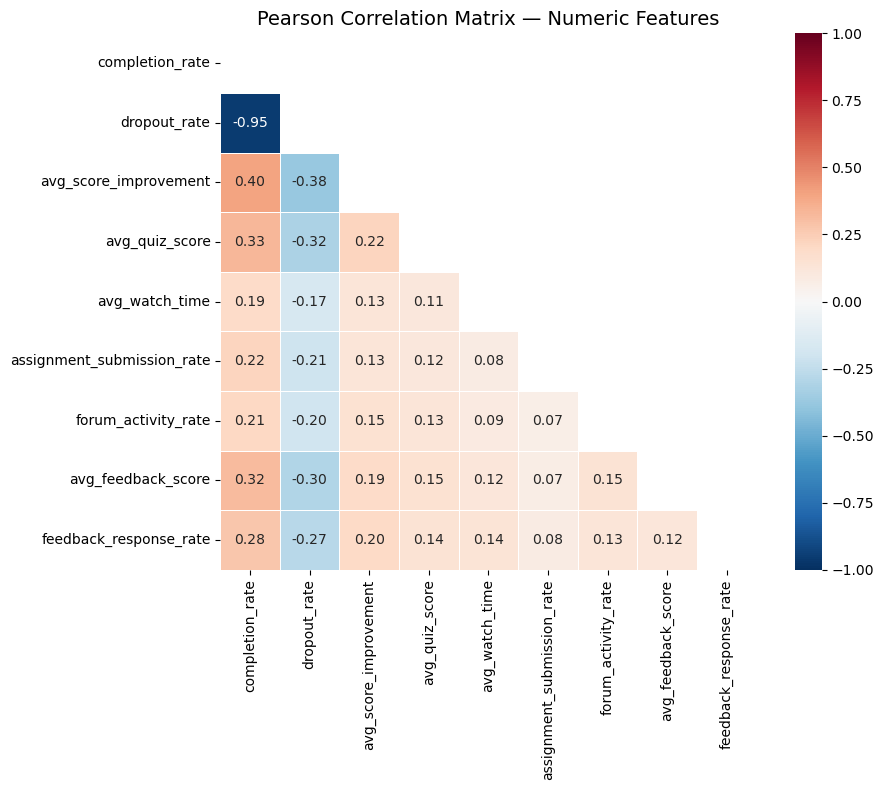

            Feature_1       Feature_2  Correlation  abs_corr
         dropout_rate completion_rate    -0.953493  0.953493
avg_score_improvement completion_rate     0.404161  0.404161
avg_score_improvement    dropout_rate    -0.381354  0.381354
       avg_quiz_score completion_rate     0.333307  0.333307
   avg_feedback_score completion_rate     0.315394  0.315394


In [9]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    square=True
)
ax.set_title('Pearson Correlation Matrix — Numeric Features', fontsize=14)
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

pairs = (
    corr.where(~np.triu(np.ones_like(corr, dtype=bool)))
    .stack()
    .reset_index()
)
pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']
pairs['abs_corr'] = pairs['Correlation'].abs()
print(pairs.sort_values('abs_corr', ascending=False).head().to_string(index=False))

completion_rate and dropout_rate are almost perfectly inversely correlated (r = −0.95) — they're redundant, so we'll drop one. avg_score_improvement has a moderate link to completion (r = 0.40). Everything else is weakly correlated, which means most features carry distinct information.

Scatter plot confirming the completion vs dropout inverse relationship.

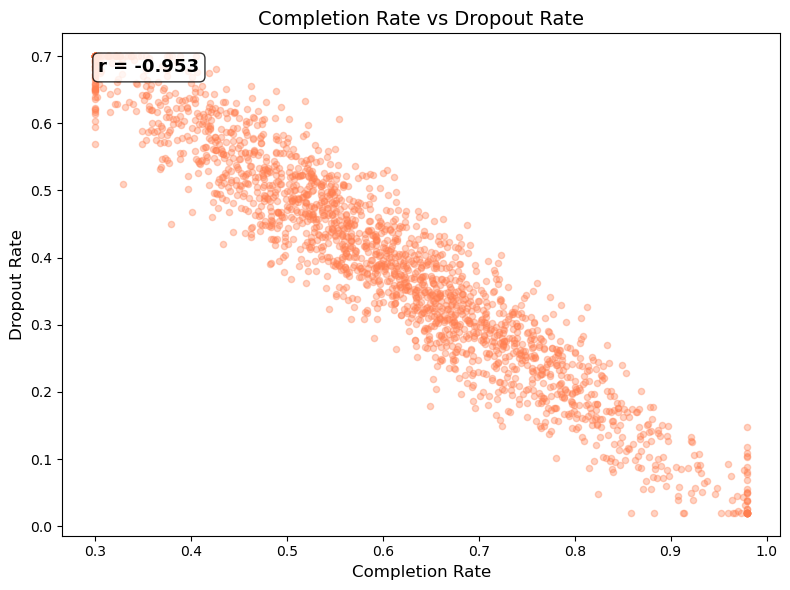

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['completion_rate'], df['dropout_rate'], alpha=0.35, s=20, color='coral')
ax.set_xlabel('Completion Rate', fontsize=12)
ax.set_ylabel('Dropout Rate', fontsize=12)
ax.set_title('Completion Rate vs Dropout Rate', fontsize=14)

r = df['completion_rate'].corr(df['dropout_rate'])
ax.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
            fontsize=13, fontweight='bold', va='top',
            bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.tight_layout()
plt.savefig('eda_completion_vs_dropout.png', dpi=150, bbox_inches='tight')
plt.show()

Boxplot of avg_feedback_score for 15 randomly sampled instructors to see within-instructor variance.

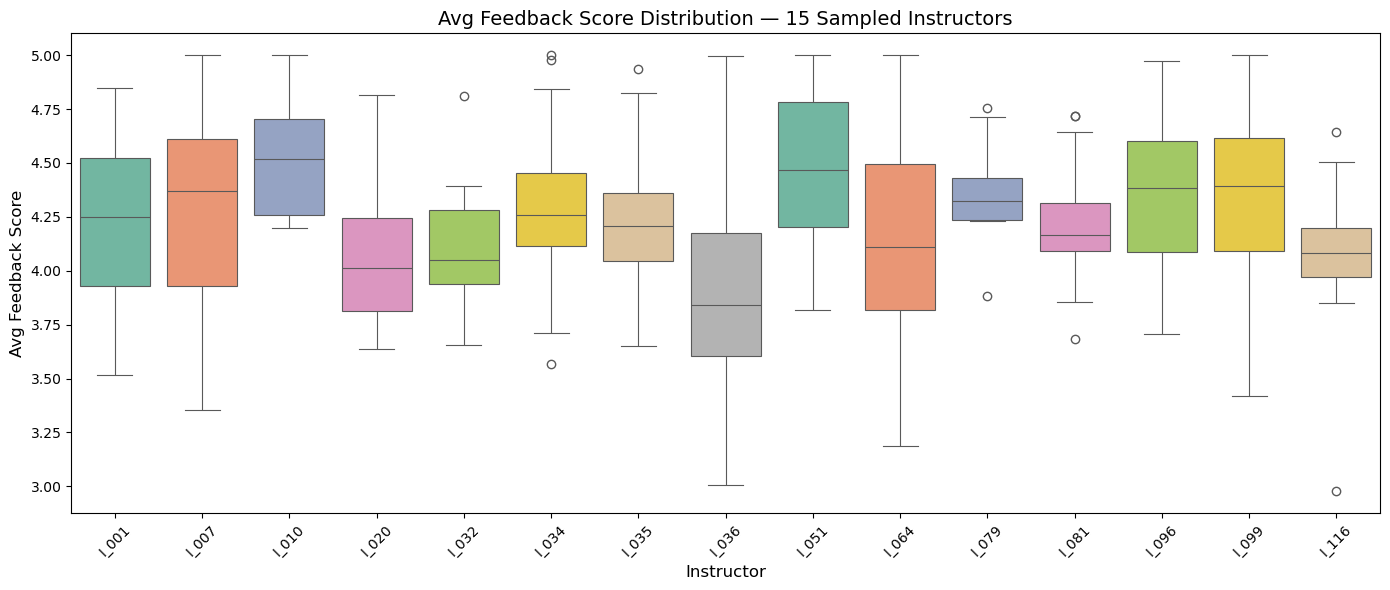

Median within-instructor std: 0.372
Overall std:                  0.419


In [11]:
np.random.seed(RANDOM_SEED)
sampled_instructors = np.random.choice(df['instructor_id'].unique(), size=15, replace=False)
sampled_instructors.sort()

df_sample = df[df['instructor_id'].isin(sampled_instructors)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=df_sample, x='instructor_id', y='avg_feedback_score',
    order=sampled_instructors, ax=ax,
    hue='instructor_id', hue_order=sampled_instructors, palette='Set2',
    legend=False, linewidth=0.8
)
ax.set_xlabel('Instructor', fontsize=12)
ax.set_ylabel('Avg Feedback Score', fontsize=12)
ax.set_title('Avg Feedback Score Distribution — 15 Sampled Instructors', fontsize=14)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('eda_feedback_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

spread = df.groupby('instructor_id')['avg_feedback_score'].agg(['std', 'count'])
print(f'Median within-instructor std: {spread["std"].median():.3f}')
print(f'Overall std:                  {df["avg_feedback_score"].std():.3f}')

Instructors vary almost as much within their own batches (std ~0.37) as the overall population (std ~0.42), so plain averages might not tell the full story. Course difficulty or cohort differences probably explain a lot of the within-instructor noise.

completion_rate and dropout_rate are redundant — drop one. Most features are roughly normal, though completion_rate has a floor at 0.30 and dropout_rate caps at 0.70 (clamping in the data). Outside that one pair, features are mostly independent. Instructor feedback scores are noisy batch-to-batch, so aggregation across batches will matter.

---

Effectiveness score: min-max scale all 8 metrics (dropping dropout_rate) to 0–1, then combine with weights — outcomes 50% (completion, score improvement, quiz score), engagement 25% (watch time, assignment submissions, forum activity), feedback 25% (feedback score, response rate). Outcomes get the most weight because they directly measure learning; engagement and feedback are useful but noisier proxies.

In [12]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

outcome_cols = ['completion_rate', 'avg_score_improvement', 'avg_quiz_score']
engagement_cols = ['avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate']
feedback_cols = ['avg_feedback_score', 'feedback_response_rate']

outcome_score = df[outcome_cols].apply(minmax).mean(axis=1)
engagement_score = df[engagement_cols].apply(minmax).mean(axis=1)
feedback_score = df[feedback_cols].apply(minmax).mean(axis=1)

df['effectiveness_score'] = (
    0.50 * outcome_score +
    0.25 * engagement_score +
    0.25 * feedback_score
)

print(df['effectiveness_score'].describe())

count    2000.000000
mean        0.591176
std         0.106431
min         0.192855
25%         0.519049
50%         0.593186
75%         0.661129
max         0.933515
Name: effectiveness_score, dtype: float64


Splitting into Low/Medium/High tiers using tertile cuts so each tier starts roughly equal-sized.

In [13]:
df['effectiveness_tier'] = pd.qcut(
    df['effectiveness_score'], q=3, labels=['Low', 'Medium', 'High']
)

print(df['effectiveness_tier'].value_counts().sort_index())
print(f'\nTier cutoffs (33rd, 67th percentile):')
cuts = df['effectiveness_score'].quantile([1/3, 2/3])
print(f'  Low/Medium boundary:  {cuts.iloc[0]:.4f}')
print(f'  Medium/High boundary: {cuts.iloc[1]:.4f}')

effectiveness_tier
Low       667
Medium    666
High      667
Name: count, dtype: int64

Tier cutoffs (33rd, 67th percentile):
  Low/Medium boundary:  0.5446
  Medium/High boundary: 0.6377


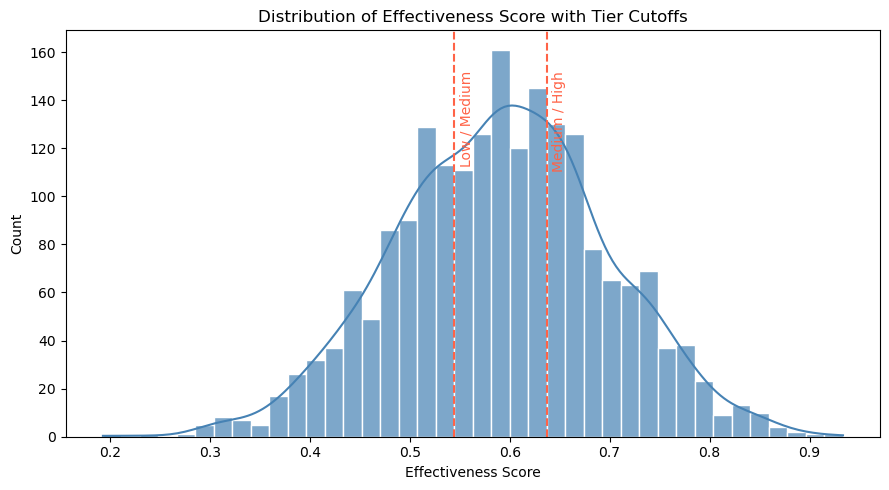

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df['effectiveness_score'], bins=40, kde=True, ax=ax,
             color='steelblue', edgecolor='white', alpha=0.7)

for q, label in zip([1/3, 2/3], ['Low / Medium', 'Medium / High']):
    val = df['effectiveness_score'].quantile(q)
    ax.axvline(val, color='tomato', linestyle='--', linewidth=1.5)
    ax.text(val + 0.005, ax.get_ylim()[1] * 0.9, label,
            rotation=90, va='top', fontsize=10, color='tomato')

ax.set_xlabel('Effectiveness Score')
ax.set_title('Distribution of Effectiveness Score with Tier Cutoffs')
plt.tight_layout()
plt.savefig('eda_effectiveness_score.png', dpi=150, bbox_inches='tight')
plt.show()